<a href="https://colab.research.google.com/github/sudhans18/ABDA/blob/main/02_LaBSE_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U sentence-transformers pandas==2.2.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 14.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/cmu_mosei"

READY_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_ready_v2.pkl"
)

EMBEDDING_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_embeddings.pkl"
)

print("Ready file:", READY_PATH)
print("Embedding output:", EMBEDDING_PATH)

Ready file: /content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.pkl
Embedding output: /content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_embeddings.pkl


In [ ]:
ready_df = pd.read_pickle(READY_PATH)

print("Shape:", ready_df.shape)
print("\nColumns:")
print(ready_df.columns.tolist())

Shape: (23253, 13)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear']


In [ ]:
assert len(ready_df) == 23253
assert "text" in ready_df.columns
assert "token_count" in ready_df.columns

print("Number of rows:", len(ready_df))
print("Missing text:", ready_df["text"].isna().sum())
print("Empty text:", (ready_df["text"].str.strip() == "").sum())
print("Duplicate rows:", ready_df.duplicated().sum())

Number of rows: 23253
Missing text: 0
Empty text: 0
Duplicate rows: 0


In [ ]:
for i in range(5):
    print(f"\nSample {i}")
    print(ready_df.iloc[i]["text"])


Sample 0
writer i see that a writer is somebody who has an incredible command of mechanics of the english language

Sample 1
key is part of the people that we use to solve those issues whether it's stretch or outdoor resistance or abrasions or different technical aspects that we really need to solve to get into new markets they've been able to bring solutions

Sample 2
businesses that we do they've been able to find solutions or at least bring some answers to the table

Sample 3
operations key polymer brings a technical aspect to our operation that we don't have internally we're

Sample 4
internally we're a huge user of adhesives for our operation called flocking and we don't have the technical inside compounding or the technical expertise to do these types of things key brings


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(
    "sentence-transformers/LaBSE",
    device=device
)

print("Device:", device)
print("Model loaded successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Device: cuda
Model loaded successfully


In [ ]:
embedding_dim = model.get_sentence_embedding_dimension()
max_length = model.max_seq_length

print("Embedding dimension:", embedding_dim)
print("Model max sequence length:", max_length)

Embedding dimension: 768
Model max sequence length: 256


/tmp/ipykernel_3733/608084918.py:1: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = model.get_sentence_embedding_dimension()


In [ ]:
tokenizer = model.tokenizer

print("Tokenizer model max length:", tokenizer.model_max_length)

Tokenizer model max length: 256


In [ ]:
print("Maximum token count:", ready_df["token_count"].max())
print("Samples > 256:", (ready_df["token_count"] > max_length).sum())

Maximum token count: 223
Samples > 256: 0


In [ ]:
print(ready_df["token_count"].describe())

count    23253.000000
mean        25.477573
std         13.778297
min          3.000000
25%         16.000000
50%         22.000000
75%         31.000000
max        223.000000
Name: token_count, dtype: float64


Pilot Embedding (before encoding all 23k samples)

In [ ]:
pilot_texts = ready_df["text"].iloc[:16].tolist()

pilot_embeddings = model.encode(
    pilot_texts,
    batch_size=16,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Pilot embedding shape:", pilot_embeddings.shape)

Pilot embedding shape: (16, 768)


In [ ]:
print("Contains NaN:", np.isnan(pilot_embeddings).any())
print("Contains Inf:", np.isinf(pilot_embeddings).any())

norms = np.linalg.norm(pilot_embeddings, axis=1)

print("Minimum norm:", norms.min())
print("Maximum norm:", norms.max())

Contains NaN: False
Contains Inf: False
Minimum norm: 0.99999994
Maximum norm: 1.0


In [ ]:
print("Embedding dimension:", len(pilot_embeddings[0]))
print("\nFirst 20 values:")
print(pilot_embeddings[0][:20])

Embedding dimension: 768

First 20 values:
[-0.01295004  0.004679   -0.0462564  -0.07088806 -0.00265373  0.01616439
 -0.0473111  -0.02446704 -0.04286124  0.01269871 -0.01097088  0.02197312
 -0.01705803 -0.06662656 -0.06371916 -0.04930012  0.02148882  0.01571123
 -0.00682016 -0.06145303]


Full Embedding Generation

In [ ]:
embedding_df = ready_df.copy()

all_texts = embedding_df["text"].tolist()

print("Number of texts:", len(all_texts))

Number of texts: 23253


In [ ]:
embeddings = model.encode(
    all_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding matrix shape:", embeddings.shape)

Batches:   0%|          | 0/727 [00:00<?, ?it/s]

Embedding matrix shape: (23253, 768)


Validating the full embedding matrix

In [ ]:
assert embeddings.shape == (len(embedding_df), 768)

print("Shape validation passed.")
print("Shape:", embeddings.shape)

Shape validation passed.
Shape: (23253, 768)


In [ ]:
print("NaN present:", np.isnan(embeddings).any())
print("Inf present:", np.isinf(embeddings).any())

assert not np.isnan(embeddings).any()
assert not np.isinf(embeddings).any()

print("Numerical validation passed.")

NaN present: False
Inf present: False
Numerical validation passed.


In [ ]:
embedding_norms = np.linalg.norm(embeddings, axis=1)

print("Minimum norm:", embedding_norms.min())
print("Maximum norm:", embedding_norms.max())
print("Mean norm:", embedding_norms.mean())

Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


In [ ]:
embedding_df["labse_embedding"] = list(embeddings)

print(embedding_df.shape)
print(embedding_df.columns.tolist())

(23253, 14)
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear', 'labse_embedding']


In [ ]:
embedding_lengths = embedding_df["labse_embedding"].apply(len)

print(embedding_lengths.value_counts())

assert (embedding_lengths == 768).all()

print("All embeddings are 768-dimensional.")

labse_embedding
768    23253
Name: count, dtype: int64
All embeddings are 768-dimensional.


In [ ]:
embedding_df.to_pickle(EMBEDDING_PATH)

print("Saved successfully:")
print(EMBEDDING_PATH)

Saved successfully:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_embeddings.pkl


In [ ]:
import json

metadata = {
    "dataset": "CMU-MOSEI",
    "feature_type": "Semantic text embeddings",
    "model": "sentence-transformers/LaBSE",
    "embedding_dimension": int(embedding_dim),
    "model_max_sequence_length": int(max_length),
    "number_of_samples": int(len(embedding_df)),
    "excluded_samples_due_to_sequence_length": 6,
    "normalization": True,
    "device": device,
    "source_file": os.path.basename(READY_PATH),
    "output_file": os.path.basename(EMBEDDING_PATH)
}

METADATA_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_embeddings_metadata.json"
)

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_embeddings_metadata.json


In [ ]:
print("=" * 60)
print("CMU-MOSEI LaBSE EMBEDDING PIPELINE COMPLETE")
print("=" * 60)

print("Samples:", len(embedding_df))
print("Embedding dimension:", embedding_dim)
print("Max sequence length:", max_length)
print("Excluded > max length:", 6)
print("NaN:", np.isnan(embeddings).any())
print("Inf:", np.isinf(embeddings).any())
print("Normalized:", True)

print("\nOutput:")
print(EMBEDDING_PATH)

print("\nMetadata:")
print(METADATA_PATH)

CMU-MOSEI LaBSE EMBEDDING PIPELINE COMPLETE
Samples: 23253
Embedding dimension: 768
Max sequence length: 256
Excluded > max length: 6
NaN: False
Inf: False
Normalized: True

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_embeddings.pkl

Metadata:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_embeddings_metadata.json


# Validation
1. PCA → What structure exists in the 768-D embedding space?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [2]:
PROJECT_DIR = "/content/drive/MyDrive/cmu_mosei"

EMBEDDING_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_embeddings.pkl"
)

embedding_df = pd.read_pickle(EMBEDDING_PATH)

print("Shape:", embedding_df.shape)
print("Columns:")
print(embedding_df.columns.tolist())

Shape: (23253, 14)
Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear', 'labse_embedding']


In [3]:
assert "labse_embedding" in embedding_df.columns
assert "text" in embedding_df.columns

print("Number of samples:", len(embedding_df))

print(
    "Embedding dimensions:",
    len(embedding_df.iloc[0]["labse_embedding"])
)

Number of samples: 23253
Embedding dimensions: 768


In [4]:
X = np.vstack(
    embedding_df["labse_embedding"].values
)

print("Embedding matrix shape:", X.shape)
print("Data type:", X.dtype)

Embedding matrix shape: (23253, 768)
Data type: float32


In [5]:
print("NaN present:", np.isnan(X).any())
print("Inf present:", np.isinf(X).any())

assert not np.isnan(X).any()
assert not np.isinf(X).any()

print("Numerical validation passed.")

NaN present: False
Inf present: False
Numerical validation passed.


In [6]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

print("Original dimensions:", X.shape[1])
print("PCA dimensions:", X_pca.shape[1])
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

Original dimensions: 768
PCA dimensions: 2
Explained variance ratio:
[0.03911229 0.02664177]
Total variance explained: 0.065754056


In [7]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "sentiment": embedding_df["sentiment"].values
})

print(pca_df.head())

        PC1       PC2  sentiment
0 -0.040147 -0.014396   1.000000
1  0.306743 -0.082763   1.000000
2  0.241344  0.055046   0.666667
3  0.172540  0.124464   0.000000
4  0.201880 -0.070992   0.000000


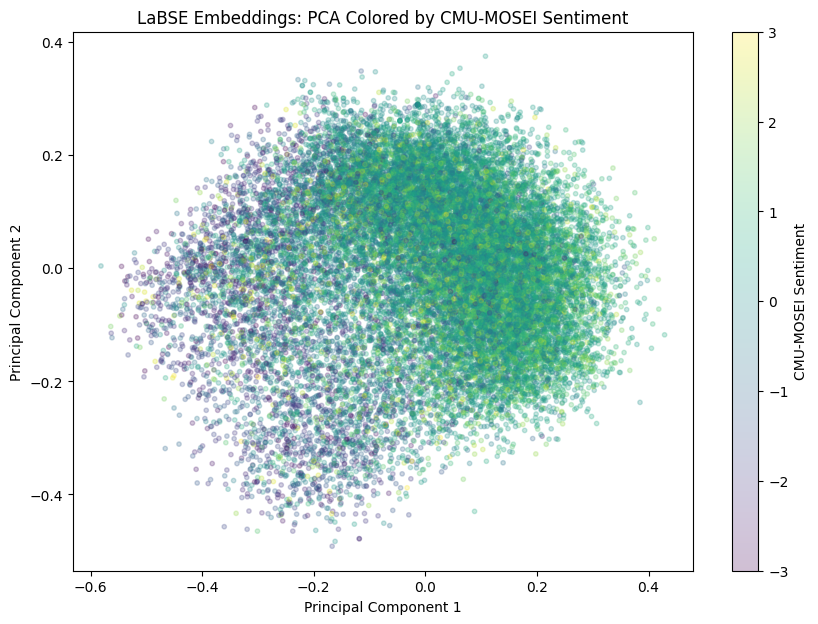

In [8]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["sentiment"],
    alpha=0.25,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("LaBSE Embeddings: PCA Colored by CMU-MOSEI Sentiment")

plt.colorbar(scatter, label="CMU-MOSEI Sentiment")

plt.show()

2. Cosine similarity → Do semantically similar texts have high similarity?

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
def compare_texts(index_a, index_b):
    text_a = embedding_df.iloc[index_a]["text"]
    text_b = embedding_df.iloc[index_b]["text"]

    emb_a = X[index_a].reshape(1, -1)
    emb_b = X[index_b].reshape(1, -1)

    similarity = cosine_similarity(
        emb_a,
        emb_b
    )[0, 0]

    print("=" * 80)
    print("TEXT A")
    print(text_a)

    print("\nTEXT B")
    print(text_b)

    print("\nCosine similarity:", round(float(similarity), 4))
    print("=" * 80)

In [10]:
for i in range(10):
    print(f"\n[{i}]")
    print(embedding_df.iloc[i]["text"])


[0]
writer i see that a writer is somebody who has an incredible command of mechanics of the english language

[1]
key is part of the people that we use to solve those issues whether it's stretch or outdoor resistance or abrasions or different technical aspects that we really need to solve to get into new markets they've been able to bring solutions

[2]
businesses that we do they've been able to find solutions or at least bring some answers to the table

[3]
operations key polymer brings a technical aspect to our operation that we don't have internally we're

[4]
internally we're a huge user of adhesives for our operation called flocking and we don't have the technical inside compounding or the technical expertise to do these types of things key brings

[5]
of things key brings those types of aspects to a business on new markets new potentials and even on our equipment of how things run and operate with a pretty big long experience with their team

[6]
solutions we have many new oppo

In [38]:
pairs = [
    (8, 9),
    (2, 6),
    (0, 7)
]

for i, (idx_a, idx_b) in enumerate(pairs, start=1):

    similarity = cosine_similarity(
        X[idx_a].reshape(1, -1),
        X[idx_b].reshape(1, -1)
    )[0, 0]

    print(f"\nPair {i}")
    print("-" * 80)

    print("A:", embedding_df.iloc[idx_a]["text"])
    print("B:", embedding_df.iloc[idx_b]["text"])

    print(
        "Cosine similarity:",
        round(float(similarity), 4)
    )


Pair 1
--------------------------------------------------------------------------------
A: it's important for teachers to understand their legal ethical and professional obligations in an educational setting
B: noncompliance can result in legal liability to you and to the school district in which you are employed
Cosine similarity: 0.4818

Pair 2
--------------------------------------------------------------------------------
A: businesses that we do they've been able to find solutions or at least bring some answers to the table
B: solutions we have many new opportunities through the way things have changed through the years looking for new niche high end value added products
Cosine similarity: 0.4041

Pair 3
--------------------------------------------------------------------------------
A: i did not like it at all
B: a place in our landscape for all students to find their niche and succeed
Cosine similarity: 0.1957


Nearest neighbors → Given a text, does LaBSE retrieve intuitively related texts?

In [12]:
nn_model = NearestNeighbors(
    n_neighbors=6,
    metric="cosine"
)

nn_model.fit(X)

print("Nearest-neighbor index built successfully.")

Nearest-neighbor index built successfully.


In [13]:
def show_nearest_neighbors(query_index, n_neighbors=5):

    distances, indices = nn_model.kneighbors(
        X[query_index].reshape(1, -1),
        n_neighbors=n_neighbors + 1
    )

    print("=" * 100)
    print("QUERY")
    print(embedding_df.iloc[query_index]["text"])

    print("\nNEAREST NEIGHBORS")
    print("=" * 100)

    for rank in range(1, len(indices[0])):

        neighbor_index = indices[0][rank]
        cosine_distance = distances[0][rank]
        cosine_similarity_value = 1 - cosine_distance

        print(f"\nRank {rank}")
        print("Index:", neighbor_index)
        print(
            "Cosine similarity:",
            round(float(cosine_similarity_value), 4)
        )
        print(
            "Text:",
            embedding_df.iloc[neighbor_index]["text"]
        )

In [40]:
show_nearest_neighbors(10000)

QUERY
base i was trying to convince the un i mean the dutch and the to allow my brother to stay at least but my brother

NEAREST NEIGHBORS

Rank 1
Index: 19339
Cosine similarity: 0.5451
Text: consideration because i've always believed that both are equally as important but generally i try to be more logical than impulsive and despite

Rank 2
Index: 9998
Cosine similarity: 0.5349
Text: i realized that the only way to survive was to remain on the compound for as long as possible with the dutch

Rank 3
Index: 12454
Cosine similarity: 0.5064
Text: i had to learn english even though i would say english is my native language

Rank 4
Index: 9191
Cosine similarity: 0.4998
Text: situation was so basically i had a friend i'm not going to mention any real names here but for the sake of clarification let's say her name was madison and madison

Rank 5
Index: 8013
Cosine similarity: 0.4832
Text: they've at first they'd asked me if i would consider not coming back to uni and to stay with them but i'v

In [18]:
pca_output = embedding_df[
    [
        "segment_id",
        "label_idx",
        "start",
        "end",
        "text",
        "sentiment"
    ]
].copy()

pca_output["PC1"] = X_pca[:, 0]
pca_output["PC2"] = X_pca[:, 1]

PCA_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_PCA2D.pkl"
)

pca_output.to_pickle(PCA_PATH)

print("PCA data saved:")
print(PCA_PATH)

PCA data saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_PCA2D.pkl


In [19]:
pca_metadata = {
    "dataset": "CMU-MOSEI",
    "model": "sentence-transformers/LaBSE",
    "original_dimension": int(X.shape[1]),
    "pca_dimension": 2,
    "pc1_explained_variance": float(
        pca.explained_variance_ratio_[0]
    ),
    "pc2_explained_variance": float(
        pca.explained_variance_ratio_[1]
    ),
    "total_explained_variance": float(
        pca.explained_variance_ratio_.sum()
    ),
    "number_of_samples": int(X.shape[0])
}

print(pca_metadata)

{'dataset': 'CMU-MOSEI', 'model': 'sentence-transformers/LaBSE', 'original_dimension': 768, 'pca_dimension': 2, 'pc1_explained_variance': 0.03911229223012924, 'pc2_explained_variance': 0.026641767472028732, 'total_explained_variance': 0.06575405597686768, 'number_of_samples': 23253}


In [41]:
similarity_results = []
similar_pairs = [
    (99, 100),
    (812, 1000),
    (800, 5875)
]

dissimilar_pairs = [
    (800, 2),
    (1000, 16715),
    (5350, 15000)
]

for idx_a, idx_b in similar_pairs:

    similarity = cosine_similarity(
        X[idx_a].reshape(1, -1),
        X[idx_b].reshape(1, -1)
    )[0, 0]

    similarity_results.append({
        "type": "semantically_related_candidate",
        "index_a": idx_a,
        "index_b": idx_b,
        "text_a": embedding_df.iloc[idx_a]["text"],
        "text_b": embedding_df.iloc[idx_b]["text"],
        "cosine_similarity": float(similarity)
    })


for idx_a, idx_b in dissimilar_pairs:

    similarity = cosine_similarity(
        X[idx_a].reshape(1, -1),
        X[idx_b].reshape(1, -1)
    )[0, 0]

    similarity_results.append({
        "type": "semantically_unrelated_candidate",
        "index_a": idx_a,
        "index_b": idx_b,
        "text_a": embedding_df.iloc[idx_a]["text"],
        "text_b": embedding_df.iloc[idx_b]["text"],
        "cosine_similarity": float(similarity)
    })


similarity_df = pd.DataFrame(similarity_results)

display(
    similarity_df[
        [
            "type",
            "cosine_similarity",
            "text_a",
            "text_b"
        ]
    ]
)

,type,cosine_similarity,text_a,text_b
0,semantically_related_candidate,0.709628,embrace it i want you to believe in this i wan...,in this i want you to be a part of this i want...
1,semantically_related_candidate,0.828898,good at all i don't like it i,i did not like it at all
2,semantically_related_candidate,0.659103,the plot it was like it didn't have a plot it ...,nothing there there's not much of a plot it's ...
3,semantically_unrelated_candidate,0.195204,the plot it was like it didn't have a plot it ...,businesses that we do they've been able to fin...
4,semantically_unrelated_candidate,0.211070,i did not like it at all,there is so much of power in poetry
5,semantically_unrelated_candidate,0.161892,didn't like it that's,a place in our landscape for all students to f...


In [42]:
SIMILARITY_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_similarity_validation.pkl"
)

similarity_df.to_pickle(SIMILARITY_PATH)

print("Similarity validation saved:")
print(SIMILARITY_PATH)

Similarity validation saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_similarity_validation.pkl


In [43]:
print("=" * 70)
print("LABSE SEMANTIC REPRESENTATION — EXPERIMENT 1 COMPLETE")
print("=" * 70)

print("\nDataset")
print("Samples:", X.shape[0])
print("Embedding dimension:", X.shape[1])

print("\nPCA")
print(
    "PC1 variance:",
    round(pca.explained_variance_ratio_[0], 4)
)
print(
    "PC2 variance:",
    round(pca.explained_variance_ratio_[1], 4)
)
print(
    "Total 2D variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

print("\nValidation experiments completed:")
print("1. PCA visualization")
print("2. Cosine similarity analysis")
print("3. Nearest-neighbor inspection")

print("\nSaved artifacts:")
print(PCA_PATH)
print(SIMILARITY_PATH)

LABSE SEMANTIC REPRESENTATION — EXPERIMENT 1 COMPLETE

Dataset
Samples: 23253
Embedding dimension: 768

PCA
PC1 variance: 0.0391
PC2 variance: 0.0266
Total 2D variance: 0.0658

Validation experiments completed:
1. PCA visualization
2. Cosine similarity analysis
3. Nearest-neighbor inspection

Saved artifacts:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_PCA2D.pkl
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_similarity_validation.pkl
